In [1]:
import sqlite3
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [2]:
connection=sqlite3.connect('olist_cohort.db') #sqlite bazasina qosuluruq

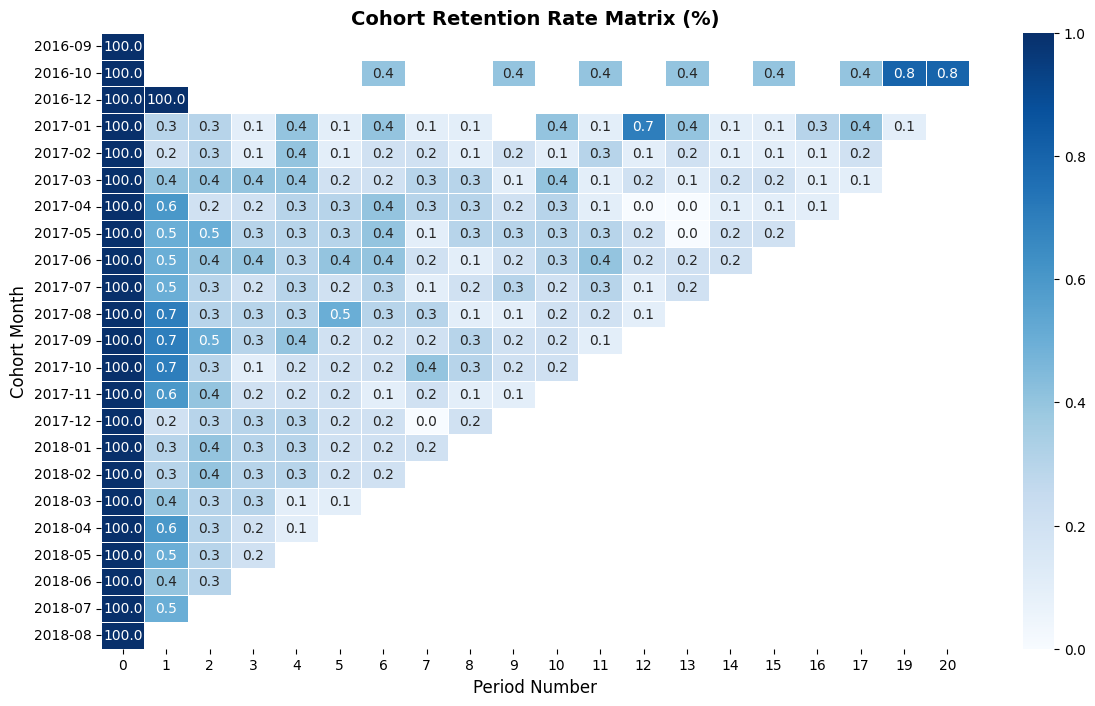

In [21]:
query_retention_matrix="""--Q1 Q2
with delivered_orders as (
select order_id,customer_id,order_purchase_timestamp
from orders
where order_status="delivered"
),
orders_with_customer as (
select o.order_id,o.customer_id,c.customer_unique_id,o.order_purchase_timestamp
from delivered_orders o
join customers c
on o.customer_id=c.customer_id  --ortaq sutun olan customer id ile iki cedveli bir birine baglayiriq belelikle her orderi sifaris edenin unique id si gorunecek
),
cohort_data as ( --her bir musterinin ilk sifaris tarixini tapiriq window func ile
Select distinct customer_unique_id,strftime('%Y-%m',min(order_purchase_timestamp) over (partition by customer_unique_id)) as cohort_month
from orders_with_customer
),
--Q3
activity as ( -- bununla ise her sifarisin hansi ayda bas verdiyine baxiriq
select distinct customer_unique_id,order_id,strftime('%Y-%m',order_purchase_timestamp) as order_month
from orders_with_customer
),
--Q4
customer_activity as ( -- indi ise cohort monthla order month i yan yana getiririk
select a.customer_unique_id,a.order_id,c.cohort_month,a.order_month
from activity a
join cohort_data c
on a.customer_unique_id=c.customer_unique_id
),
activity_with_period as (
SELECT customer_unique_id,order_id,cohort_month,order_month,
( -- strftime ile tarixden ili ve ayi cixardiriq, cast ile str leri integer e ceviririk,sifaris illerini cixib 12 ye vurub aya ceviririk daha sonra aylari cixib evvelki netice ile toplayiriq
(Cast(strftime('%Y',order_month || '-01') as INTEGER)-CAST(strftime('%Y',cohort_month || '-01') as INTEGER))*12
+ --belelikle period ferqini tapiriq
(CAST(strftime('%m',order_month || '-01') as INTEGER)-Cast(strftime('%m',cohort_month || '-01') as INTEGER))
) as period_time
from customer_activity
),
--Q5
retention_counts as ( --burda her cohort ve period ucun nece ferqli customer oldugunu hesabalyib matrix yaradiriq
select cohort_month,period_time,count(distinct customer_unique_id) as active_customers
from activity_with_period
group by cohort_month,period_time
),
--Q6
cohort_sizes as ( --cohort size period 0 daki musteri sayi demekdir buna gore de sertde period u 0 a beraberlesdiririk
select cohort_month,count(distinct customer_unique_id) as cohort_size
from activity_with_period
where period_time=0
group by cohort_month
),
--Q7
retention_rates as ( --retention i faiz olaraq gosteririk aktiv musterileri ilk perioddaki musteri sayina bolerek
select r.cohort_month,r.period_time,r.active_customers,c.cohort_size,
round(100.0*r.active_customers/c.cohort_size,1) as retention_rate
from retention_counts r
join cohort_sizes c
on r.cohort_month=c.cohort_month
)
select cohort_month, period_time, retention_rate
from retention_rates;"""

df_retention=pd.read_sql(query_retention_matrix,connection) #sorgunu bazadan cekib dataframe e ceviririk

#pivot table yaradiriq
pivot_retention_matrix = df_retention.pivot(index='cohort_month', columns='period_time', values='retention_rate')

#heatmap vizualizasiyası
plt.figure(figsize=(14, 8))
sns.heatmap(pivot_retention_matrix,
            annot=True,#her bir xananin icinde uygun reqemin yazilmasini temin edir
            fmt=',.1f',#reqem noqteden sonra yalniz bir reqemle gosterile biler
            cmap='Blues',#reng palitrasidir tund mavidən aciq maviyə dogru deyisecek
            vmin=0,#period 0 da onsuzda retention rate 100% oldugu ucun hamisinda tund reng gosterirdi bunun qarsisini almaq ucun skalani mehdudlasdiririq
            vmax=1,
            cbar=True, #sag terefde color bar yaradilir
            linewidths=0.5)
plt.title('Cohort Retention Rate Matrix (%)',fontsize=14,fontweight='bold')
plt.xlabel('Period Number',fontsize=12)
plt.ylabel('Cohort Month',fontsize=12)
plt.show()




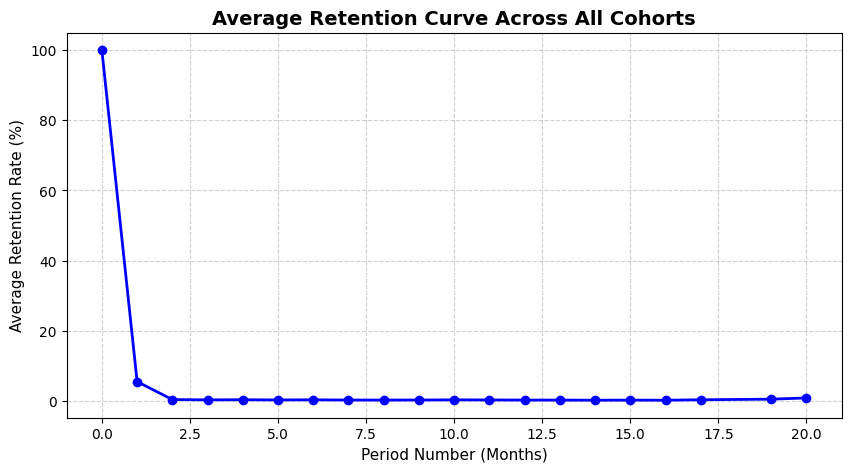

In [22]:
query_curve="""
--Q1 Q2
with delivered_orders as (
select order_id,customer_id,order_purchase_timestamp
from orders
where order_status="delivered"
),
orders_with_customer as (
select o.order_id,o.customer_id,c.customer_unique_id,o.order_purchase_timestamp
from delivered_orders o
join customers c
on o.customer_id=c.customer_id  --ortaq sutun olan customer id ile iki cedveli bir birine baglayiriq belelikle her orderi sifaris edenin unique id si gorunecek
),
cohort_data as ( --her bir musterinin ilk sifaris tarixini tapiriq window func ile
Select distinct customer_unique_id,strftime('%Y-%m',min(order_purchase_timestamp) over (partition by customer_unique_id)) as cohort_month
from orders_with_customer
),
--Q3
activity as ( -- bununla ise her sifarisin hansi ayda bas verdiyine baxiriq
select distinct customer_unique_id,order_id,strftime('%Y-%m',order_purchase_timestamp) as order_month
from orders_with_customer
),
--Q4
customer_activity as ( -- indi ise cohort monthla order month i yan yana getiririk
select a.customer_unique_id,a.order_id,c.cohort_month,a.order_month
from activity a
join cohort_data c
on a.customer_unique_id=c.customer_unique_id
),
activity_with_period as (
SELECT customer_unique_id,order_id,cohort_month,order_month,
( -- strftime ile tarixden ili ve ayi cixardiriq, cast ile str leri integer e ceviririk,sifaris illerini cixib 12 ye vurub aya ceviririk daha sonra aylari cixib evvelki netice ile toplayiriq
(Cast(strftime('%Y',order_month || '-01') as INTEGER)-CAST(strftime('%Y',cohort_month || '-01') as INTEGER))*12
+ --belelikle period ferqini tapiriq
(CAST(strftime('%m',order_month || '-01') as INTEGER)-Cast(strftime('%m',cohort_month || '-01') as INTEGER))
) as period_time
from customer_activity
),
--Q5
retention_counts as ( --burda her cohort ve period ucun nece ferqli customer oldugunu hesabalyib matrix yaradiriq
select cohort_month,period_time,count(distinct customer_unique_id) as active_customers
from activity_with_period
group by cohort_month,period_time
),
--Q6
cohort_sizes as ( --cohort size period 0 daki musteri sayi demekdir buna gore de sertde period u 0 a beraberlesdiririk
select cohort_month,count(distinct customer_unique_id) as cohort_size
from activity_with_period
where period_time=0
group by cohort_month
),
--Q7
retention_rates as ( --retention i faiz olaraq gosteririk aktiv musterileri ilk perioddaki musteri sayina bolerek
select r.cohort_month,r.period_time,r.active_customers,c.cohort_size,
round(100.0*r.active_customers/c.cohort_size,1) as retention_rate
from retention_counts r
join cohort_sizes c
on r.cohort_month=c.cohort_month
)
select period_time, round(avg(retention_rate), 2) as avg_retention_rate
from retention_rates
group by period_time
order by period_time;
"""
df_curve=pd.read_sql(query_curve,connection)
#line chart vizuali
plt.figure(figsize=(10, 5))
plt.plot(
    df_curve['period_time'],
    df_curve['avg_retention_rate'],
    marker='o',
    color='b',
    linestyle='-',
    linewidth=2,
)
plt.title('Average Retention Curve Across All Cohorts', fontsize=14, fontweight='bold')
plt.xlabel('Period Number (Months)', fontsize=11)
plt.ylabel('Average Retention Rate (%)', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()


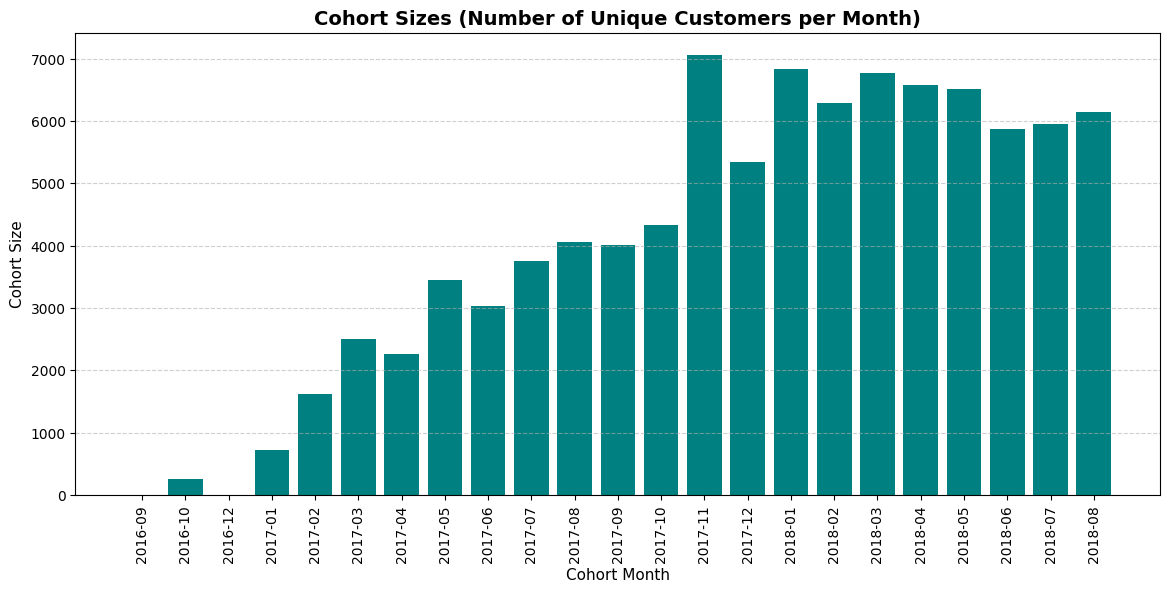

In [24]:
query_sizes="""
--Q1 Q2
with delivered_orders as (
select order_id,customer_id,order_purchase_timestamp
from orders
where order_status="delivered"
),
orders_with_customer as (
select o.order_id,o.customer_id,c.customer_unique_id,o.order_purchase_timestamp
from delivered_orders o
join customers c
on o.customer_id=c.customer_id  --ortaq sutun olan customer id ile iki cedveli bir birine baglayiriq belelikle her orderi sifaris edenin unique id si gorunecek
),
cohort_data as ( --her bir musterinin ilk sifaris tarixini tapiriq window func ile
Select distinct customer_unique_id,strftime('%Y-%m',min(order_purchase_timestamp) over (partition by customer_unique_id)) as cohort_month
from orders_with_customer
),
--Q3
activity as ( -- bununla ise her sifarisin hansi ayda bas verdiyine baxiriq
select distinct customer_unique_id,order_id,strftime('%Y-%m',order_purchase_timestamp) as order_month
from orders_with_customer
),
--Q4
customer_activity as ( -- indi ise cohort monthla order month i yan yana getiririk
select a.customer_unique_id,a.order_id,c.cohort_month,a.order_month
from activity a
join cohort_data c
on a.customer_unique_id=c.customer_unique_id
),
activity_with_period as (
SELECT customer_unique_id,order_id,cohort_month,order_month,
( -- strftime ile tarixden ili ve ayi cixardiriq, cast ile str leri integer e ceviririk,sifaris illerini cixib 12 ye vurub aya ceviririk daha sonra aylari cixib evvelki netice ile toplayiriq
(Cast(strftime('%Y',order_month || '-01') as INTEGER)-CAST(strftime('%Y',cohort_month || '-01') as INTEGER))*12
+ --belelikle period ferqini tapiriq
(CAST(strftime('%m',order_month || '-01') as INTEGER)-Cast(strftime('%m',cohort_month || '-01') as INTEGER))
) as period_time
from customer_activity
)
select cohort_month, count(distinct customer_unique_id) as cohort_size
from activity_with_period where period_time = 0 group by cohort_month;
"""
df_sizes = pd.read_sql(query_sizes, connection)

#bar chart vizuali
plt.figure(figsize=(14, 6))
plt.bar(df_sizes['cohort_month'], df_sizes['cohort_size'], color='teal') #teal firuzeyi rengidir
plt.title('Cohort Sizes (Number of Unique Customers per Month)', fontsize=14, fontweight='bold')
plt.xlabel('Cohort Month', fontsize=11)
plt.ylabel('Cohort Size', fontsize=11)
plt.xticks(rotation=90) #iller yerlessin deye 90 derece donderirik
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()